In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

### Modelo teórico

Tomado del curso Nucleos activos de galaxias, UNAL - 2026

**Ecuacion 4.1.56**

$$R_{SII}=\frac{j_{6716}}{j_{6731}} = \frac{F_{6716}}{F_{6731}} = \frac{3A_{6716}}{2A_{6731}} \Big( \frac{N_e C + 0.26A_{6731}}{N_e C + 0.26A_{6716}} \Big)$$

$$R_{OII}=\frac{j_{3729}}{j_{3726}} = \frac{F_{3729}}{F_{3726}} = \frac{3A_{3729}}{2A_{3726}} \Big( \frac{N_e C + 1.6A_{3726}}{N_e C + 1.6A_{3729}} \Big)$$

**Ecuación 4.1.57**

$$\frac{F_{5007} + F_{4959}}{F_{4363}} = 0.054e^{\frac{32.985}{T}}\frac{\frac{N_e}{\sqrt{T}}+2.6\times 10^5(1+0.12e^{-\frac{32.985}{T}})}{\frac{N_e}{\sqrt{T}}+1.627}$$

$$\frac{F_{6543} + F_{6583}}{F_{5755}} = 0.01e^{\frac{25.007}{T}}\frac{\frac{N_e}{\sqrt{T}}+1.3\times 10^5(1+0.12e^{-\frac{25.007}{T}})}{\frac{N_e}{\sqrt{T}}+250.4}$$


Notas:

- las líneas espectrales SII 6716 y NII 5755 no se encuentran en GalSpecLine, así que para el desarollo del código se utiliza SII 6717, y se excluye la ecuación 2.1.51-2. 

In [3]:
# Coeficientes de Einstein [s^-1]
A6717 = 2.6e-4;  A6731 = 8.8e-4
A3729 = 3.6e-5;  A3726 = 1.6e-4

In [4]:
# Ecuaciones

def ratio_SII(T, Ne):
    C = 8.63e-6 / np.sqrt(T)
    return (3*A6717)/(2*A6731) * (Ne*C + 0.26*A6731) / (Ne*C + 0.26*A6717)

def ratio_OII(T, Ne):
    C = 8.63e-6 / np.sqrt(T)
    return (3*A3729)/(2*A3726) * (Ne*C + 1.6*A3726) / (Ne*C + 1.6*A3729)

def ratio_OIII(T, Ne=0.0):
    x = Ne / np.sqrt(T)
    num = x + 2.6e5 * (1 + 0.12 * np.exp(-32985 / T))
    den = x + 1627
    return 0.054 * np.exp(32985 / T) * num / den

def ratio_NII(T, Ne=0.0):
    return (0.01 * np.exp(25000 / T)
        * ((Ne / np.sqrt(T) + 1.3e5 * (1 + 0.12 * np.exp(-25000 / T))) / (Ne / np.sqrt(T) + 250.4)))

### Soluciones teóricas

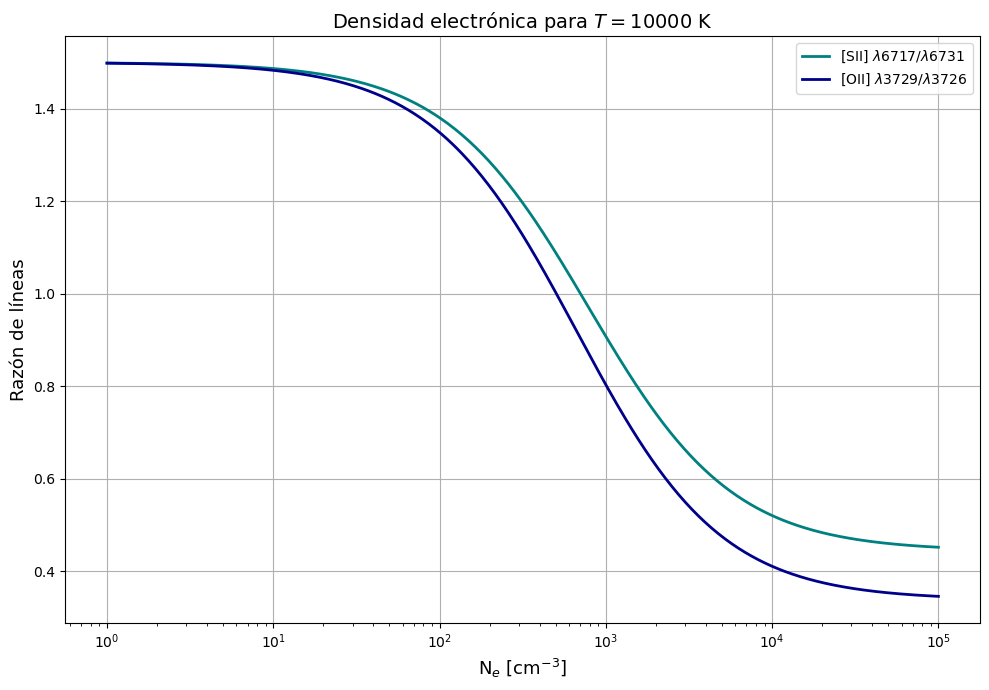

In [5]:
# Constantes
T = 10000 #K
C = 8.63e-6 / np.sqrt(T)

# Rango de densidades electrónicas
Ne = np.logspace(0, 5, 500)

# Ratios teóricos
R_to = ratio_OII(T, Ne)
R_ts = ratio_SII(T, Ne)

plt.figure(figsize=(10,7))
plt.semilogx(Ne,R_ts,linewidth=2,label=r"[SII] $\lambda 6717/ \lambda 6731$", c="teal")
plt.semilogx(Ne,R_to,linewidth=2,label=r"[OII] $\lambda 3729/ \lambda 3726$", c= "darkblue")
plt.xlabel(r"N$_e$ [cm$^{-3}$]", fontsize=13)
plt.ylabel(r"Razón de líneas",fontsize=13)
plt.title(r"Densidad electrónica para $T = 10000\ \mathrm{K}$ ",fontsize=14 )
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

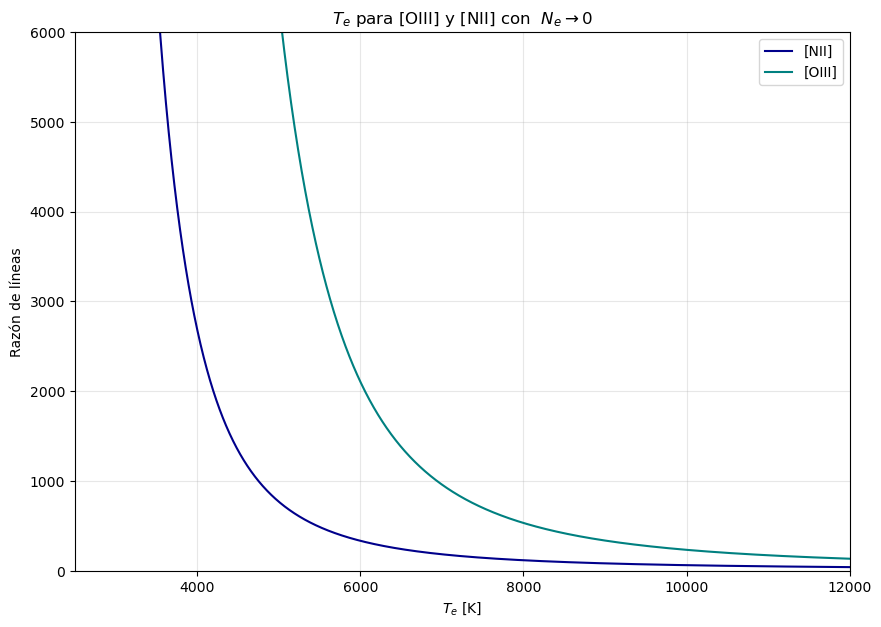

In [6]:
# Temperaturas electrónicas
Te = np.linspace(2000, 15000, 3000)

# Aproximación Ne -> 0
Ne = 0.0


Roiii = ratio_OIII(Te, Ne)
Rnii = ratio_NII(Te, Ne)

plt.figure(figsize=(10,7))
plt.plot(Te, Rnii, label="[NII]", c="darkblue")
plt.plot(Te, Roiii, label="[OIII]", c="teal")
plt.xlabel(r"$T_e$ [K]")
plt.ylabel("Razón de líneas")
plt.title(r"$T_e$ para [OIII] y [NII] con  $N_e \to 0$")
plt.ylim(0, 6000)
plt.xlim(2500, 12000)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### $T_e$ y $N_e$ para datos de QSO - SkyServer SDSS

In [7]:
# Razones experimentales y propagación de error 

def ratio_err(f1, e1, f2, e2):
    r = f1 / f2
    return r * np.sqrt((e1/f1)**2 + (e2/f2)**2)

def chi2(params, obs, errs):
    T  = 10**params[0]
    Ne = 10**params[1]
    models = np.array([ratio_SII(T,Ne), ratio_OII(T,Ne), ratio_OIII(T,Ne)])
    mask = np.isfinite(obs) & np.isfinite(errs) & (errs > 0)
    return np.sum(((obs[mask] - models[mask]) / errs[mask])**2)

In [8]:
df = pd.read_csv("data_sdss.csv", comment="#")
N = len(df["plate"])

results = []
for _, row in df.iterrows():

    # Razones 
    R_SII  = row["sii_6717_flux"]  / row["sii_6731_flux"]
    R_OII  = row["oii_3729_flux"]  / row["oii_3726_flux"]
    R_OIII = (row["oiii_5007_flux"] + row["oiii_4959_flux"]) / row["oiii_4363_flux"]

    # Propagación de errores
    eR_SII  = ratio_err(row["sii_6717_flux"],  row["sii_6717_flux_err"],
                        row["sii_6731_flux"],  row["sii_6731_flux_err"])
    eR_OII  = ratio_err(row["oii_3729_flux"],  row["oii_3729_flux_err"],
                        row["oii_3726_flux"],  row["oii_3726_flux_err"])
    eR_OIII = ratio_err(row["oiii_5007_flux"] + row["oiii_4959_flux"],
                        np.sqrt(row["oiii_5007_flux_err"]**2 + row["oiii_4959_flux_err"]**2),
                        row["oiii_4363_flux"], row["oiii_4363_flux_err"])

    obs  = np.array([R_SII,  R_OII,  R_OIII])
    errs = np.array([eR_SII, eR_OII, eR_OIII])
    valid = np.isfinite(obs) & np.isfinite(errs) & (errs > 0)
    dof = valid.sum() - 2

    res = minimize(chi2, x0=[4.0, 2.0], args=(obs, errs),
                   method="L-BFGS-B",
                   bounds=[(3.7, 5.2),   # T: 5000–160000 K
                           (0.0, 6.0)])  # Ne: 1–10⁶ cm⁻³

    T_best  = 10**res.x[0]
    Ne_best = 10**res.x[1]
    hit_bound = (T_best > 49000) | (T_best < 5500) | (Ne_best > 9e5) | (Ne_best < 1.5)
    chi2_val = res.fun
    chi2_red = chi2_val / dof if dof > 0 else np.nan

    results.append({
        "plate"    : row["plate"],
        "fiberid"  : row["fiberid"],
        "z"        : row["z"],
        "T_e"      : T_best,
        "N_e"      : Ne_best,
        "chi2"     : chi2_val,
        "chi2_red" : chi2_red,
        "dof"      : dof,
        "success"  : res.success,
        "hit_bound": hit_bound,
    })

results_df = pd.DataFrame(results)


In [9]:
# Filtro del dataset

good_mask = (results_df["success"]) & (~results_df["hit_bound"]) & (results_df["chi2_red"] <= 5)

results_good = results_df[good_mask].copy()
results_bad  = results_df[~good_mask].copy()
results_good.to_csv('data_clean.csv', index=False)

print(f"\nObjetos totales         : {len(results_df)}")
print(f"Resultados confiables   : {len(results_good)}")
print(f"Objetos excluidos       : {len(results_bad)}")
print(f"   - no converge     : {(~results_df['success']).sum()}")
print(f"   - hit bounds      : {results_df['hit_bound'].sum()}")
print(f"   - chi2_red > 5    : {(results_df['chi2_red'] > 5).sum()}")

# Summary table
#print("--------------------------------------")
#print("\nResumen:\n")
#print(results_good[["fiberid","z","T_e","N_e"]].to_string())



Objetos totales         : 1292
Resultados confiables   : 534
Objetos excluidos       : 758
   - no converge     : 0
   - hit bounds      : 286
   - chi2_red > 5    : 578


**Plots**

Número de objetos estudiados = 534


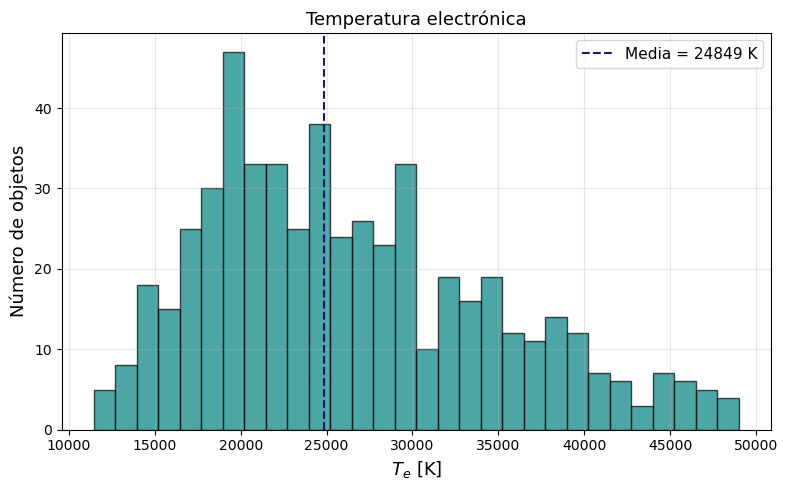

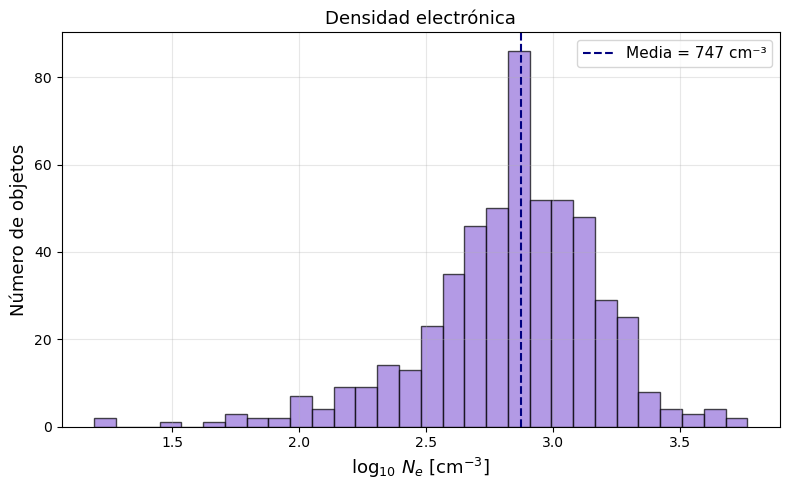

In [10]:
Ne_grid = np.logspace(0, 6, 300)
T_grid  = np.logspace(3.7, 5.2, 300)
T_fix   = 10000;  Ne_fix = 100


buenos  = results_good
pegados = results_df[ results_df["hit_bound"]]
idx_b   = buenos.index

R_SII_obs  = df["sii_6717_flux"]  / df["sii_6731_flux"]
R_OII_obs  = df["oii_3729_flux"]  / df["oii_3726_flux"]
R_OIII_obs = (df["oiii_5007_flux"] + df["oiii_4959_flux"]) / df["oiii_4363_flux"]

print(f"Número de objetos estudiados = {len(results_good["z"])}")

# ── Figura 1: histograma T_e ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
Te_buenos = buenos["T_e"].values
ax1.hist(Te_buenos, bins=30, color="teal", edgecolor="k", alpha=0.7)
ax1.axvline(np.median(Te_buenos), color="midnightblue", ls="--", lw=1.5,
            label=f"Media = {np.median(Te_buenos):.0f} K")
ax1.set_xlabel("$T_e$ [K]", fontsize=13)
ax1.set_ylabel("Número de objetos", fontsize=13)
ax1.set_title("Temperatura electrónica", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figura 2: histograma N_e ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
Ne_buenos = buenos["N_e"].values
ax2.hist(np.log10(Ne_buenos), bins=30, color="mediumpurple", edgecolor="k", alpha=0.7)
ax2.axvline(np.log10(np.median(Ne_buenos)), color="navy", ls="--", lw=1.5,
            label=f"Media = {np.median(Ne_buenos):.0f} cm⁻³")
ax2.set_xlabel("$\\log_{10}\\,N_e$ [cm$^{-3}$]", fontsize=13)
ax2.set_ylabel("Número de objetos", fontsize=13)
ax2.set_title(f"Densidad electrónica", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


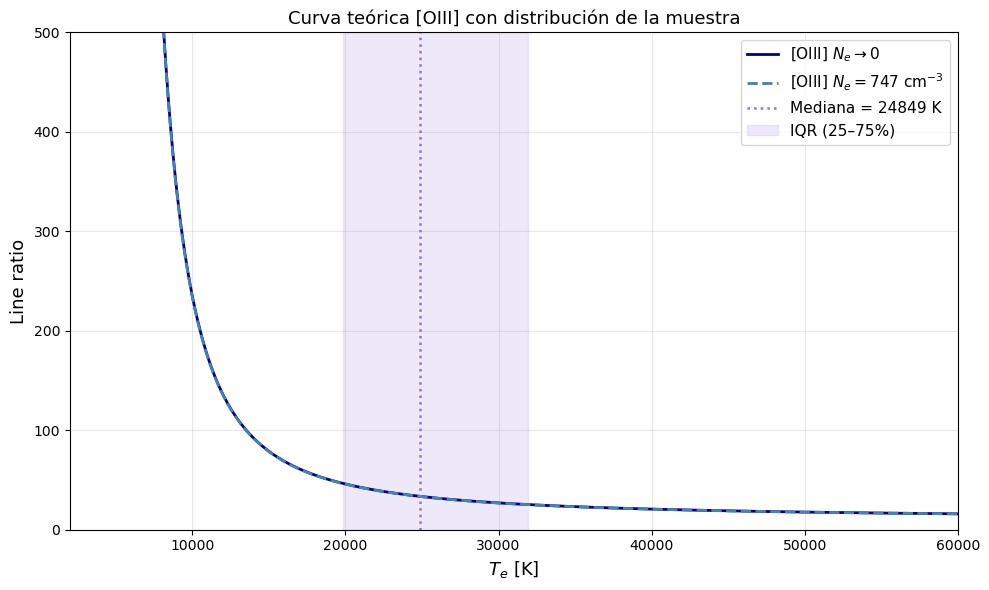

In [11]:
Te = np.linspace(2000, 60000, 3000)
Ne_median = np.median(results_good["N_e"])

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["darkblue", "steelblue"]  # sólida, punteada

for Ne_val, ls, lbl, color in zip([0.0, Ne_median], ["-", "--"],
                            [r"$N_e \to 0$", rf"$N_e = {Ne_median:.0f}$ cm$^{{-3}}$"],
                            colors):
    Roiii = ratio_OIII(Te, Ne_val)
    ax.plot(Te, Roiii, ls=ls, lw=2, label=f"[OIII] {lbl}", c=color)

# Mediana e IQR de la muestra
T_med = np.median(results_good["T_e"])
T_p25 = np.percentile(results_good["T_e"], 25)
T_p75 = np.percentile(results_good["T_e"], 75)

ax.axvline(T_med, color="mediumpurple", ls=":", lw=1.8, label=f"Mediana = {T_med:.0f} K")
ax.axvspan(T_p25, T_p75, alpha=0.15, color="mediumpurple", label="IQR (25–75%)")

ax.set_xlabel(r"$T_e$ [K]", fontsize=13)
ax.set_ylabel("Line ratio", fontsize=13)
ax.set_title(r"Curva teórica [OIII] con distribución de la muestra", fontsize=13)
ax.set_xlim(2000, 60000)
ax.set_ylim(0, 500)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

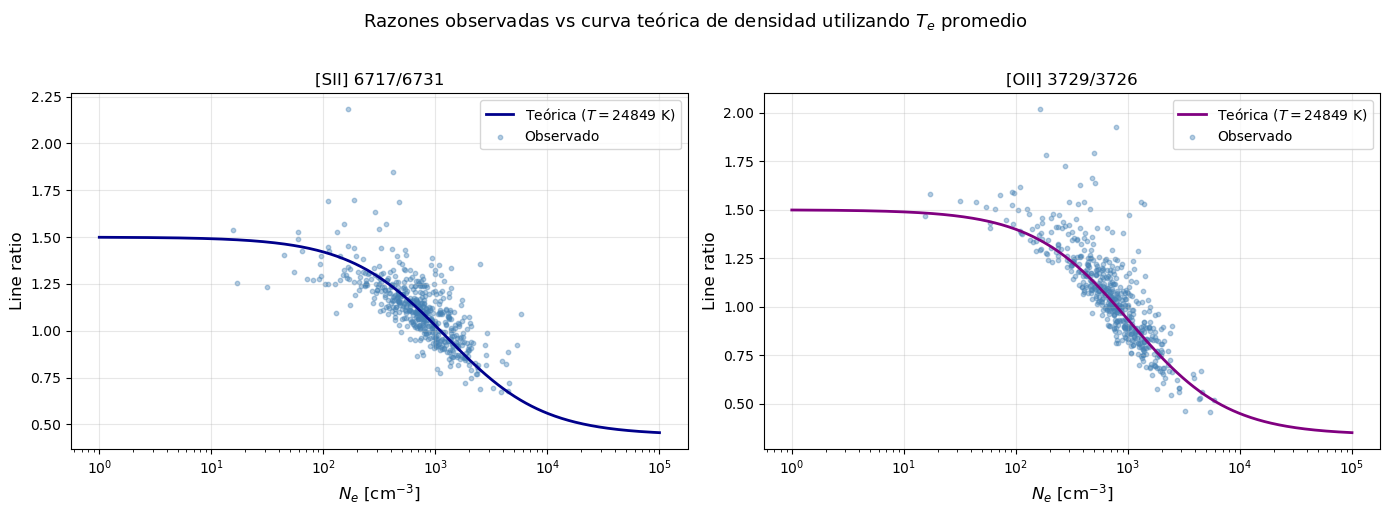

In [12]:
Ne_grid = np.logspace(0, 5, 500)
T_med   = np.median(results_good["T_e"])

R_SII_obs  = df.loc[idx_b, "sii_6717_flux"] / df.loc[idx_b, "sii_6731_flux"]
R_OII_obs  = df.loc[idx_b, "oii_3729_flux"] / df.loc[idx_b, "oii_3726_flux"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, R_obs, R_func, label, color in zip(
    axes,
    [R_SII_obs, R_OII_obs],
    [ratio_SII, ratio_OII],
    ["[SII] 6717/6731", "[OII] 3729/3726"],
    ["darkblue", "purple"]
):
    # Curva teórica a T mediana
    R_theo = R_func(T_med, Ne_grid)
    ax.semilogx(Ne_grid, R_theo, lw=2, color=color,
                label=rf"Teórica ($T = {T_med:.0f}$ K)")

    # Puntos observados vs Ne ajustada
    ax.scatter(results_good["N_e"].values, R_obs.values,
               s=10, alpha=0.4, color="steelblue", label="Observado")

    ax.set_xlabel(r"$N_e$ [cm$^{-3}$]", fontsize=12)
    ax.set_ylabel("Line ratio", fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(r"Razones observadas vs curva teórica de densidad utilizando $T_e$ promedio", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()